# 

In [10]:
from os import system,path
import json
import pandas as pd
from glob import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#system('wget "https://predictioncenter.org/casp16/assessors/RESULTS/ost/R1264/" -q --no-host-directories --cut-dirs=4 --recursive --no-parent --user ???? --password ????')
#system('wget "https://predictioncenter.org/casp16/assessors/RESULTS/ost/R1263/" -q --no-host-directories --cut-dirs=4 --recursive --no-parent --user ??? --password ????')


R1261
tm_score >= 0.45: 175, 73.52941176470588%
tm_score >= 0.7: 4, 1.680672268907563%
tm_score >= 0.8: 0, 0.0%
tm_score >= 0.9: 0, 0.0%
R1262
tm_score >= 0.45: 177, 77.97356828193833%
tm_score >= 0.7: 1, 0.4405286343612335%
tm_score >= 0.8: 0, 0.0%
tm_score >= 0.9: 0, 0.0%
R1263
tm_score >= 0.45: 140, 61.40350877192983%
tm_score >= 0.7: 72, 31.57894736842105%
tm_score >= 0.8: 51, 22.36842105263158%
tm_score >= 0.9: 40, 17.543859649122805%
R1264
tm_score >= 0.45: 128, 58.986175115207374%
tm_score >= 0.7: 54, 24.88479262672811%
tm_score >= 0.8: 0, 0.0%
tm_score >= 0.9: 0, 0.0%


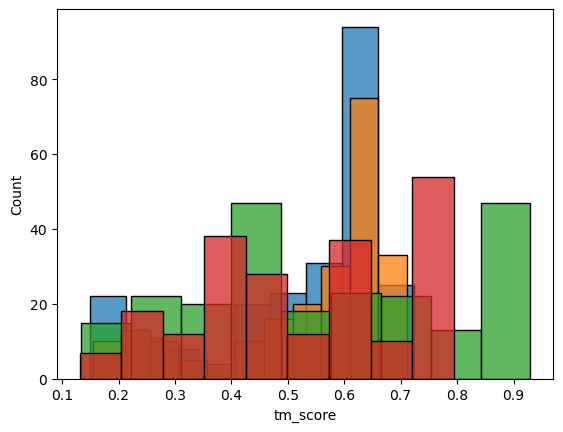

In [2]:
monomer_df = pd.read_csv('../../NA_CASP_assessment/raw_scores/RNA_monomer_results_table.csv')
R1261_rna = monomer_df[monomer_df.target=="R1261"]
R1262_rna = monomer_df[monomer_df.target=="R1262"]
R1263_rna = monomer_df[monomer_df.target=="R1263"]
R1264_rna = monomer_df[monomer_df.target=="R1264"]
sns.histplot(R1261_rna.tm_score)
sns.histplot(R1262_rna.tm_score)
sns.histplot(R1263_rna.tm_score)
sns.histplot(R1264_rna.tm_score)
for i,df in enumerate([R1261_rna,R1262_rna,R1263_rna,R1264_rna]):
    print(f'R126{i+1}')
    for cutoff in [0.45,0.7,0.8,0.9]:
        print(f'tm_score >= {cutoff}: {(df.tm_score>cutoff).sum()}, {(df.tm_score>cutoff).mean()*100}%')
plt.show()

R1261
pli lddt max 0.9182077050209044
pli lddt >= 0.45: 26, 61.904761904761905%
pli lddt >= 0.7: 21, 50.0%
pli lddt >= 0.75: 19, 45.23809523809524%
pli lddt >= 0.8: 17, 40.476190476190474%
pli lddt >= 0.9: 4, 9.523809523809524%
R1262
pli lddt max 0.8928571343421936
pli lddt >= 0.45: 19, 45.23809523809524%
pli lddt >= 0.7: 14, 33.33333333333333%
pli lddt >= 0.75: 13, 30.952380952380953%
pli lddt >= 0.8: 11, 26.190476190476193%
pli lddt >= 0.9: 0, 0.0%
R1263
pli lddt max 0.9807692170143129
pli lddt >= 0.45: 19, 46.34146341463415%
pli lddt >= 0.7: 16, 39.02439024390244%
pli lddt >= 0.75: 15, 36.58536585365854%
pli lddt >= 0.8: 15, 36.58536585365854%
pli lddt >= 0.9: 7, 17.073170731707318%
R1264
pli lddt max 1.0
pli lddt >= 0.45: 19, 45.23809523809524%
pli lddt >= 0.7: 16, 38.095238095238095%
pli lddt >= 0.75: 14, 33.33333333333333%
pli lddt >= 0.8: 13, 30.952380952380953%
pli lddt >= 0.9: 7, 16.666666666666664%


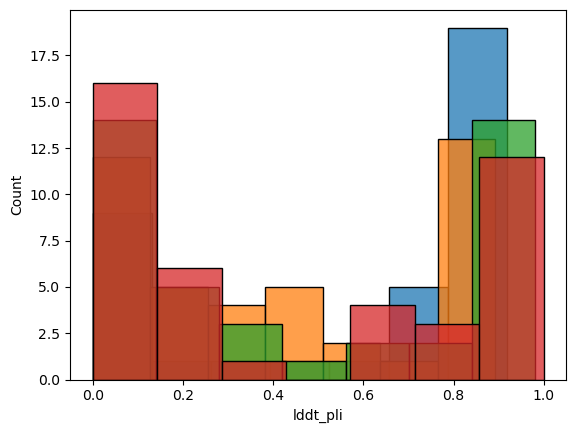

In [7]:
R1261_ligand = pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1261v1.RESULTS').lddt_pli
R1262_ligand = pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1262v1.RESULTS').lddt_pli
R1263_ligand = pd.merge(pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1263v1A.RESULTS'), pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1263v1B.RESULTS'), 
                     on='model', suffixes=('_df1', '_df2'))
R1263_ligand = R1263_ligand[['lddt_pli_df1', 'lddt_pli_df2']].max(axis=1)
R1264_ligand = pd.merge(pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1264v1A.RESULTS'), pd.read_csv('../../NA_CASP_assessment/raw_scores/ligand/R1264v1B.RESULTS'), 
                     on='model', suffixes=('_df1', '_df2'))
R1264_ligand = R1264_ligand[['lddt_pli_df1', 'lddt_pli_df2']].max(axis=1)
sns.histplot(R1261_ligand)
sns.histplot(R1262_ligand)
sns.histplot(R1263_ligand)
sns.histplot(R1264_ligand)
for i,df in enumerate([R1261_ligand,R1262_ligand,R1263_ligand,R1264_ligand]):
    print(f'R126{i+1}')
    print('pli lddt max',df.max())
    for cutoff in [0.45,0.7,0.75,0.8,0.9]:
        print(f'pli lddt >= {cutoff}: {(df>cutoff).sum()}, {(df>cutoff).mean()*100}%')
plt.show()

In [11]:
# care about TM-score ranges

# care about the lddt pli
# and then for 63 v 64 check out the lddt local of C52


R1263_C52_lddt = []
R1264_C52_lddt = []

for file in glob('R1263/*/ost/ost*json'):
    name = path.split(file)[1]
    with open(file, 'r') as f:
        data = json.load(f)
        C52_lddt = data['local_lddt']['0.52.']
        #print(name,C52_lddt)
        R1263_C52_lddt.append(C52_lddt)


for file in glob('R1264/*/ost/ost*json'):
    name = path.split(file)[1]
    with open(file, 'r') as f:
        data = json.load(f)
        C52_lddt = data['local_lddt']['0.52.']
        #print(name,C52_lddt)
        R1264_C52_lddt.append(C52_lddt)

R1263
local lddt >= 0.45: 135, 61.92660550458715%
local lddt >= 0.7: 72, 33.02752293577982%
local lddt >= 0.8: 63, 28.899082568807337%
local lddt >= 0.9: 38, 17.431192660550458%
R1264
local lddt >= 0.45: 131, 63.28502415458937%
local lddt >= 0.7: 0, 0.0%
local lddt >= 0.8: 0, 0.0%
local lddt >= 0.9: 0, 0.0%


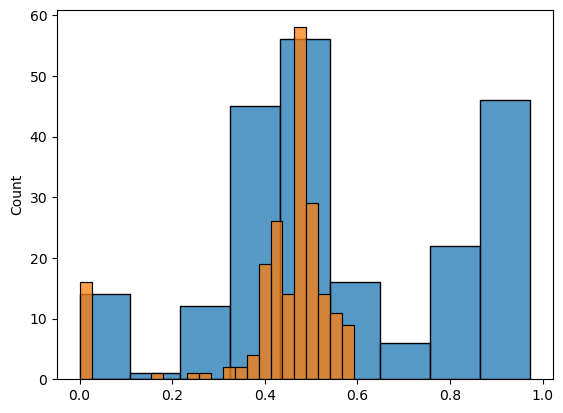

In [12]:
sns.histplot(R1263_C52_lddt)
sns.histplot(R1264_C52_lddt)
for i,df in enumerate([R1263_C52_lddt,R1264_C52_lddt]):
    df = np.array(df)
    print(f'R126{i+3}')
    for cutoff in [0.45,0.7,0.8,0.9]:
        print(f'local lddt >= {cutoff}: {(df>cutoff).sum()}, {(df>cutoff).mean()*100}%')

In [14]:
R1263_lddt = []
R1264_lddt = []

for file in glob('R1263/*/ost/ost*json'):
    name = path.split(file)[1]
    with open(file, 'r') as f:
        data = json.load(f)
        lddt = data['local_lddt']
        for chain,score in lddt.items():
            R1263_lddt.append({'residue':int(chain.split('.')[1]),'lddt':score})
R1263_lddt = pd.DataFrame(R1263_lddt)

for file in glob('R1264/*/ost/ost*json'):
    name = path.split(file)[1]
    with open(file, 'r') as f:
        data = json.load(f)
        lddt = data['local_lddt']
        for chain,score in lddt.items():
            
            R1264_lddt.append({'residue':int(chain.split('.')[1]),'lddt':score})
R1264_lddt = pd.DataFrame(R1264_lddt)

(0.0, 1.0)

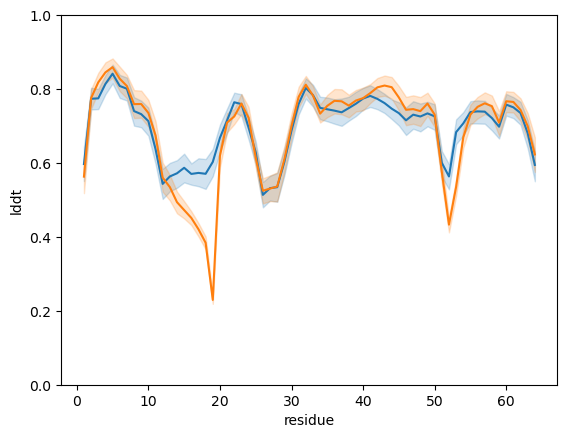

In [15]:
sns.lineplot(R1263_lddt,x='residue',y='lddt')
sns.lineplot(R1264_lddt,x='residue',y='lddt')
plt.ylim(0,1)